
# 🧬 Breast Cancer Classification Using CNN

### 1. BreaKHis Histopathological Image Classification

This notebook develops a Convolutional Neural Network (CNN) to classify breast histopathology images into two categories:

- **Benign**
- **Malignant**

The project includes dataset preparation, preprocessing, CNN model development, training, evaluation, and model interpretation.

The notebook is designed for execution in Google Colab using Google Drive for dataset storage.


## 2. Project Workflow

This notebook follows a structured workflow for developing and evaluating a CNN-based breast cancer classification model.

The main stages are:

1. Import required libraries
2. Configure the project and ensure reproducibility
3. Locate and load the BreaKHis dataset
4. Inspect and understand the dataset
5. Analyze class distribution
6. Prepare training, validation, and test data
7. Check and prevent data leakage
8. Preprocess the histopathology images
9. Apply data augmentation
10. Build a baseline CNN model
11. Train the baseline model
12. Evaluate the baseline model
13. Perform controlled CNN experiments
14. Handle class imbalance
15. Compare experimental results
16. Select the final model configuration
17. Train the final model
18. Evaluate the final model using detailed classification metrics
19. Visualize the confusion matrix and ROC curve
20. Test the model on individual images
21. Save and reload the trained model
22. Summarize the final results


## 3. Import Required Libraries

The following libraries will be used throughout the notebook for:

* File and path management
* Numerical operations
* Data manipulation
* Data visualization
* Image processing
* CNN model development
* Model training and evaluation
* Classification metrics
* Confusion matrix and ROC-AUC analysis

The libraries will be imported using the Google Colab Python environment.



In [ ]:
# ============================================================
# 3. IMPORT REQUIRED LIBRARIES
# ============================================================

# File and path management
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Model evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# Class imbalance
from sklearn.utils.class_weight import compute_class_weight

# Display
from IPython.display import display

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 4. Configuration & Reproducibility

Before working with the dataset, we define the main configuration values used throughout the notebook.

These settings include:

* Image size
* Batch size
* Number of classes
* Random seed
* Dataset path
* Model output path

A fixed random seed helps make experiments more reproducible by reducing differences caused by random initialization and data shuffling.


In [ ]:
# ============================================================
# 4. CONFIGURATION & REPRODUCIBILITY
# ============================================================

# Reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Training configuration
BATCH_SIZE = 32

# Classification configuration
NUM_CLASSES = 2
CLASS_NAMES = ["Benign", "Malignant"]

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/CNN_Breast_Cancer"
)

# Dataset ZIP file
ZIP_PATH = PROJECT_ROOT / "Dataset.zip"

# Extracted dataset directory
EXTRACT_ROOT = PROJECT_ROOT / "extracted_dataset"

# Model output directory
MODEL_DIR = PROJECT_ROOT / "models"

# Results directory
RESULTS_DIR = PROJECT_ROOT / "results"

# Create required directories
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("=" * 60)
print("Project Configuration")
print("=" * 60)

print(f"\nRandom seed       : {SEED}")
print(f"Image size        : {IMAGE_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Number of classes : {NUM_CLASSES}")
print(f"Class names       : {CLASS_NAMES}")

print("\nProject root:")
print(PROJECT_ROOT)

print("\nDataset ZIP:")
print(ZIP_PATH)

print("\nExtraction directory:")
print(EXTRACT_ROOT)

print("\nModel directory:")
print(MODEL_DIR)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nConfiguration completed successfully.")

Project Configuration

Random seed       : 42
Image size        : (224, 224)
Batch size        : 32
Number of classes : 2
Class names       : ['Benign', 'Malignant']

Project root:
/content/drive/MyDrive/CNN_Breast_Cancer

Dataset ZIP:
/content/drive/MyDrive/CNN_Breast_Cancer/Dataset.zip

Extraction directory:
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset

Model directory:
/content/drive/MyDrive/CNN_Breast_Cancer/models

Results directory:
/content/drive/MyDrive/CNN_Breast_Cancer/results

Configuration completed successfully.


## 5. Locate and Verify the BreaKHis Dataset

In this section, we inspect the dataset ZIP file and verify its internal folder structure before extraction.

The dataset is expected to contain histopathological breast tissue images categorized into two classes:

- **Benign**
- **Malignant**

We will inspect the ZIP contents to identify the correct dataset structure and avoid making assumptions about the extracted folder paths.

In [ ]:
# ============================================================
# 5. LOCATE AND VERIFY THE BREAkHIS DATASET
# ============================================================

import zipfile

print("=" * 60)
print("Inspecting Dataset ZIP")
print("=" * 60)

# Verify that the ZIP file exists
if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Dataset ZIP file was not found at:\n{ZIP_PATH}"
    )

print(f"\nZIP file found:")
print(ZIP_PATH)

# Display ZIP file size
zip_size_gb = ZIP_PATH.stat().st_size / (1024 ** 3)
print(f"\nZIP file size: {zip_size_gb:.2f} GB")

# Inspect ZIP contents
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    file_list = zip_ref.namelist()

print(f"\nTotal entries in ZIP: {len(file_list):,}")

print("\nFirst 50 entries in the ZIP:")
print("-" * 60)

for item in file_list[:50]:
    print(item)

print("\nZIP inspection completed successfully.")

Inspecting Dataset ZIP

ZIP file found:
/content/drive/MyDrive/CNN_Breast_Cancer/Dataset.zip

ZIP file size: 1.68 GB

Total entries in ZIP: 15,818

First 50 entries in the ZIP:
------------------------------------------------------------
BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria/100X/benign/SOB_B_A-14-22549AB-100-001.png
BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria/100X/benign/SOB_B_A-14-22549AB-100-002.png
BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria/100X/benign/SOB_B_A-14-22549AB-100-003.png
BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria/100X/benign/SOB_B_A-14-22549AB-100-004.png
BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_binaria/100X/benign/SOB_B_A-14-22549AB-100-005.p

## 6. Extract the BreaKHis Dataset

The dataset is stored as a ZIP file in the project directory.

In this section, we extract the dataset into the designated extraction directory. Extraction will be skipped if the dataset has already been extracted, preventing unnecessary duplication and processing time.

In [ ]:
# ============================================================
# 6. EXTRACT THE BREAkHIS DATASET
# ============================================================

import zipfile
import shutil

print("=" * 60)
print("Dataset Extraction")
print("=" * 60)

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Dataset ZIP file not found:\n{ZIP_PATH}"
    )

# Check whether the extraction directory already contains files
existing_files = list(EXTRACT_ROOT.rglob("*"))

if len(existing_files) > 0:
    print("\nDataset extraction directory is not empty.")
    print(f"Extraction directory: {EXTRACT_ROOT}")
    print(f"Existing entries: {len(existing_files):,}")
    print("\nSkipping extraction to avoid duplicate files.")

else:
    print("\nStarting dataset extraction...")
    print(f"Source ZIP: {ZIP_PATH}")
    print(f"Destination: {EXTRACT_ROOT}")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_ROOT)

    print("\nDataset extracted successfully.")

# Display extracted directory information
all_extracted_items = list(EXTRACT_ROOT.rglob("*"))
extracted_files = [
    item for item in all_extracted_items
    if item.is_file()
]

print("\nExtraction Summary")
print("-" * 60)
print(f"Extraction directory : {EXTRACT_ROOT}")
print(f"Total files          : {len(extracted_files):,}")
print(f"Total entries        : {len(all_extracted_items):,}")

Dataset Extraction

Dataset extraction directory is not empty.
Extraction directory: /content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset
Existing entries: 15,871

Skipping extraction to avoid duplicate files.

Extraction Summary
------------------------------------------------------------
Extraction directory : /content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset
Total files          : 15,818
Total entries        : 15,871


## 7. Explore the Extracted Dataset Structure

After extraction, we inspect the directory structure recursively.

This step helps us identify:

- The root directory of the dataset
- Available class folders
- Histopathological image files
- The correct path for subsequent data processing

The dataset path will be determined from the extracted files rather than assumed in advance.

In [ ]:
# ============================================================
# 7. EXPLORE THE EXTRACTED DATASET STRUCTURE
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".tif",
    ".tiff",
    ".bmp"
}

print("=" * 60)
print("Exploring Extracted Dataset Structure")
print("=" * 60)

if not EXTRACT_ROOT.exists():
    raise FileNotFoundError(
        f"Extraction directory not found:\n{EXTRACT_ROOT}"
    )

# Collect all files and image files
all_files = [
    item for item in EXTRACT_ROOT.rglob("*")
    if item.is_file()
]

image_files = [
    item for item in all_files
    if item.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"\nExtraction root:")
print(EXTRACT_ROOT)

print(f"\nTotal files: {len(all_files):,}")
print(f"Image files: {len(image_files):,}")

# Display the first 30 image paths
print("\nFirst 30 image paths:")
print("-" * 60)

for image_path in image_files[:30]:
    print(image_path)

# Display the top-level directories
top_level_directories = [
    item for item in EXTRACT_ROOT.iterdir()
    if item.is_dir()
]

print("\nTop-level directories:")
print("-" * 60)

for directory in top_level_directories:
    print(directory.name)

print("\nDataset structure inspection completed.")

Exploring Extracted Dataset Structure

Extraction root:
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset

Total files: 15,818
Image files: 15,818

First 30 image paths:
------------------------------------------------------------
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse/40X/adenosis/SOB_B_A-14-22549AB-40-001.png
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse/40X/adenosis/SOB_B_A-14-22549AB-40-002.png
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse/40X/adenosis/SOB_B_A-14-22549AB-40-003.png
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/d

## 8. Verify Dataset Categories

The BreaKHis dataset contains images organized according to magnification and histopathological subtype.

In this section, we inspect the available directory categories, including:

- Magnification levels
- Benign tissue subtypes
- Malignant tissue subtypes

This verification will help us create a binary classification dataset containing:

- **Benign**
- **Malignant**

In [ ]:
# ============================================================
# 8. VERIFY DATASET CATEGORIES
# ============================================================

print("=" * 60)
print("Verifying Dataset Categories")
print("=" * 60)

# Define the observed dataset root
DATASET_ROOT = (
    EXTRACT_ROOT
    / "BreakHis - Breast Cancer Histopathological Database"
    / "dataset_cancer_v1"
    / "dataset_cancer_v1"
)

MULTICLASS_PATH = DATASET_ROOT / "classificacao_multiclasse"

if not MULTICLASS_PATH.exists():
    raise FileNotFoundError(
        f"Multiclass dataset directory not found:\n{MULTICLASS_PATH}"
    )

print("\nDataset root:")
print(DATASET_ROOT)

print("\nMulticlass dataset path:")
print(MULTICLASS_PATH)

# Identify magnification directories
magnification_directories = sorted([
    directory
    for directory in MULTICLASS_PATH.iterdir()
    if directory.is_dir()
])

print("\nMagnification directories:")
print("-" * 60)

for directory in magnification_directories:
    print(directory.name)

# Display subdirectories under each magnification
print("\nSubtypes by magnification:")
print("-" * 60)

for magnification_directory in magnification_directories:
    print(f"\n{magnification_directory.name}:")

    subtype_directories = sorted([
        directory
        for directory in magnification_directory.iterdir()
        if directory.is_dir()
    ])

    for subtype_directory in subtype_directories:
        image_count = sum(
            1
            for file_path in subtype_directory.rglob("*")
            if file_path.is_file()
            and file_path.suffix.lower() in IMAGE_EXTENSIONS
        )

        print(
            f"  {subtype_directory.name:<25} "
            f"{image_count:>5,} images"
        )

print("\nDataset category verification completed successfully.")

Verifying Dataset Categories

Dataset root:
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1

Multiclass dataset path:
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse

Magnification directories:
------------------------------------------------------------
100X
200X
400X
40X

Subtypes by magnification:
------------------------------------------------------------

100X:
  adenosis                    113 images
  ductal_carcinoma            903 images
  fibroadenoma                260 images
  lobular_carcinoma           170 images
  mucinous_carcinoma          222 images
  papillary_carcinoma         142 images
  phyllodes_tumor             121 images
  tubular_adenoma             150 images

200X:
  adenosis                    111 images
  ductal_carcinoma            

## 9. Define the Dataset Path

The dataset contains multiclass histopathological subtypes. For this project, these subtypes will later be grouped into two major categories:

- **Benign**
- **Malignant**

The current dataset path points to the multiclass directory. We will inspect its complete structure before constructing the binary classification records.

In [ ]:
# ============================================================
# 9. DEFINE THE DATASET PATH
# ============================================================

DATASET_PATH = MULTICLASS_PATH

print("=" * 60)
print("Dataset Path Configuration")
print("=" * 60)

print("\nDataset path:")
print(DATASET_PATH)

print(f"\nDataset path exists: {DATASET_PATH.exists()}")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset path does not exist:\n{DATASET_PATH}"
    )

print("\nDataset path configured successfully.")

Dataset Path Configuration

Dataset path:
/content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse

Dataset path exists: True

Dataset path configured successfully.


## 10. Create Dataset Records

Each image will be represented as a dataset record containing:

- Image path
- Histopathological subtype
- Binary class label
- Magnification level
- Specimen identifier

The multiclass subtypes will be grouped into the two binary classification categories: Benign and Malignant.

In [ ]:
# ============================================================
# 10. CREATE DATASET RECORDS
# ============================================================

print("=" * 60)
print("Creating Dataset Records")
print("=" * 60)

# Define subtype-to-class mapping
BENIGN_SUBTYPES = {
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma"
}

MALIGNANT_SUBTYPES = {
    "ductal_carcinoma",
    "lobular_carcinoma",
    "mucinous_carcinoma",
    "papillary_carcinoma"
}

SUBTYPE_TO_CLASS = {
    subtype: "Benign"
    for subtype in BENIGN_SUBTYPES
}

SUBTYPE_TO_CLASS.update({
    subtype: "Malignant"
    for subtype in MALIGNANT_SUBTYPES
})

# Collect image records
dataset_records = []

for magnification_directory in sorted(MULTICLASS_PATH.iterdir()):

    if not magnification_directory.is_dir():
        continue

    magnification = magnification_directory.name

    for subtype_directory in sorted(magnification_directory.iterdir()):

        if not subtype_directory.is_dir():
            continue

        subtype = subtype_directory.name

        # Validate subtype
        if subtype not in SUBTYPE_TO_CLASS:
            print(f"Warning: Unrecognized subtype: {subtype}")
            continue

        binary_class = SUBTYPE_TO_CLASS[subtype]

        for image_path in sorted(subtype_directory.rglob("*")):

            if (
                image_path.is_file()
                and image_path.suffix.lower() in IMAGE_EXTENSIONS
            ):

                image_name = image_path.stem

                # Extract specimen identifier
                # Example:
                # SOB_B_A-14-22549AB-40-001
                name_parts = image_name.split("-")

                if len(name_parts) >= 4:
                    specimen_id = "-".join(name_parts[:-2])
                else:
                    specimen_id = image_name

                dataset_records.append({
                    "image_path": str(image_path),
                    "subtype": subtype,
                    "binary_class": binary_class,
                    "magnification": magnification,
                    "specimen_id": specimen_id
                })

# Convert records to DataFrame
dataset_df = pd.DataFrame(dataset_records)

if dataset_df.empty:
    raise ValueError("No image records were created.")

print("\nDataset records created successfully.")

print(f"\nTotal image records: {len(dataset_df):,}")

print("\nDataFrame columns:")
print(dataset_df.columns.tolist())

print("\nFirst five records:")
display(dataset_df.head())

Creating Dataset Records

Dataset records created successfully.

Total image records: 7,909

DataFrame columns:
['image_path', 'subtype', 'binary_class', 'magnification', 'specimen_id']

First five records:


,image_path,subtype,binary_class,magnification,specimen_id
0,/content/drive/MyDrive/CNN_Breast_Cancer/extra...,adenosis,Benign,100X,SOB_B_A-14-22549AB
1,/content/drive/MyDrive/CNN_Breast_Cancer/extra...,adenosis,Benign,100X,SOB_B_A-14-22549AB
2,/content/drive/MyDrive/CNN_Breast_Cancer/extra...,adenosis,Benign,100X,SOB_B_A-14-22549AB
3,/content/drive/MyDrive/CNN_Breast_Cancer/extra...,adenosis,Benign,100X,SOB_B_A-14-22549AB
4,/content/drive/MyDrive/CNN_Breast_Cancer/extra...,adenosis,Benign,100X,SOB_B_A-14-22549AB


## 11. Inspect the Binary Class Distribution

The dataset contains multiple histopathological subtypes that have been grouped into two binary classes:

- Benign
- Malignant

In this section, we calculate the number of images in each class and visualize the distribution.

This analysis helps identify potential class imbalance before model training.

Binary Class Distribution

Number of images per class:
binary_class
Benign       2480
Malignant    5429
Name: count, dtype: int64

Class percentages:


,Image Count,Percentage
binary_class,,
Benign,2480,31.36
Malignant,5429,68.64


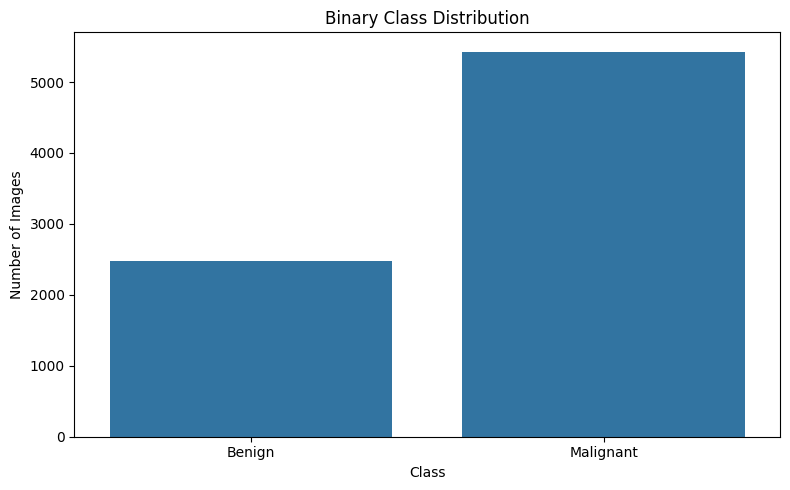

In [ ]:
# ============================================================
# 11. INSPECT CLASS DISTRIBUTION
# ============================================================

print("=" * 60)
print("Binary Class Distribution")
print("=" * 60)

class_distribution = (
    dataset_df["binary_class"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("\nNumber of images per class:")
print(class_distribution)

print("\nClass percentages:")
class_percentages = (
    class_distribution / class_distribution.sum() * 100
).round(2)

display(
    pd.DataFrame({
        "Image Count": class_distribution,
        "Percentage": class_percentages
    })
)

# Plot class distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_distribution.index,
    y=class_distribution.values
)

plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## 12. Analyze Magnification Distribution

The BreaKHis dataset contains images captured at different magnification levels:

- 40X
- 100X
- 200X
- 400X

In this section, we analyze the number of images available at each magnification level.

This helps us understand the distribution of image samples across different magnification settings.

Magnification Distribution

Number of images per magnification:


,Image Count
magnification,
100X,2081
200X,2013
400X,1820
40X,1995


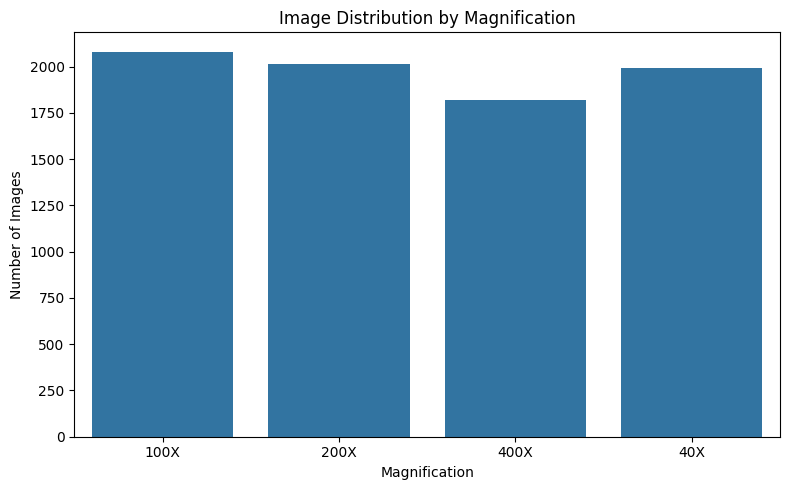

In [ ]:
# ============================================================
# 12. ANALYZE MAGNIFICATION DISTRIBUTION
# ============================================================

print("=" * 60)
print("Magnification Distribution")
print("=" * 60)

magnification_distribution = (
    dataset_df["magnification"]
    .value_counts()
    .sort_index()
)

print("\nNumber of images per magnification:")
display(magnification_distribution.to_frame("Image Count"))

# Plot magnification distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    x=magnification_distribution.index,
    y=magnification_distribution.values
)

plt.title("Image Distribution by Magnification")
plt.xlabel("Magnification")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## 13. Analyze Histopathological Subtype Distribution

The dataset contains eight histopathological subtypes.

In this section, we calculate the number of images for each subtype. This provides a more detailed view of the dataset composition before binary classification.

Histopathological Subtype Distribution

Number of images per subtype:


,Image Count
subtype,
ductal_carcinoma,3451
fibroadenoma,1014
mucinous_carcinoma,792
lobular_carcinoma,626
tubular_adenoma,569
papillary_carcinoma,560
phyllodes_tumor,453
adenosis,444


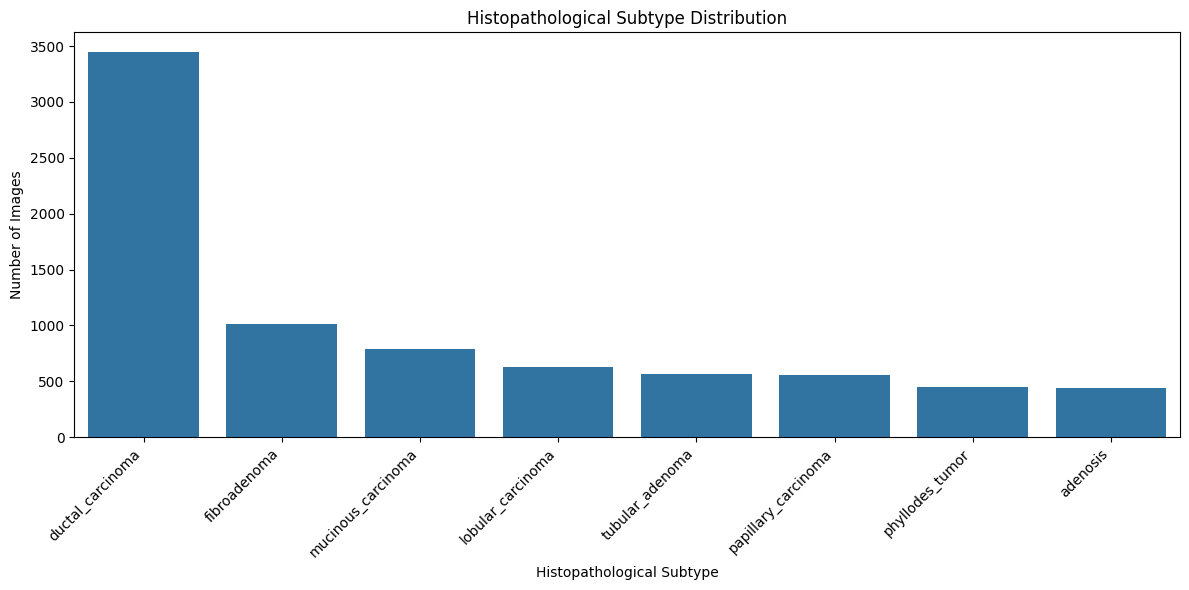

In [ ]:
# ============================================================
# 13. ANALYZE HISTOPATHOLOGICAL SUBTYPE DISTRIBUTION
# ============================================================

print("=" * 60)
print("Histopathological Subtype Distribution")
print("=" * 60)

subtype_distribution = (
    dataset_df["subtype"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nNumber of images per subtype:")
display(subtype_distribution.to_frame("Image Count"))

# Plot subtype distribution
plt.figure(figsize=(12, 6))

sns.barplot(
    x=subtype_distribution.index,
    y=subtype_distribution.values
)

plt.title("Histopathological Subtype Distribution")
plt.xlabel("Histopathological Subtype")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Analyze Class Distribution by Magnification

In this section, we examine the distribution of Benign and Malignant images across the different magnification levels.

This comparison helps identify whether the binary classes are distributed consistently across magnifications.

Class Distribution by Magnification

Image counts by magnification and binary class:


binary_class,Benign,Malignant
magnification,,
100X,644,1437
200X,623,1390
400X,588,1232
40X,625,1370


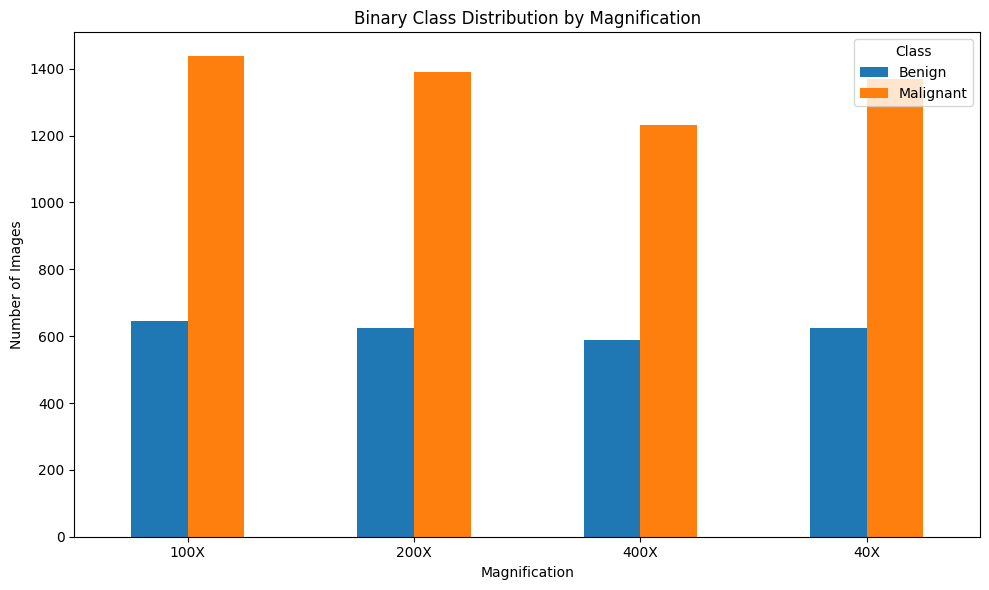

In [ ]:
# ============================================================
# 14. CLASS DISTRIBUTION BY MAGNIFICATION
# ============================================================

print("=" * 60)
print("Class Distribution by Magnification")
print("=" * 60)

class_magnification_table = pd.crosstab(
    dataset_df["magnification"],
    dataset_df["binary_class"]
)

class_magnification_table = class_magnification_table.reindex(
    columns=CLASS_NAMES,
    fill_value=0
)

print("\nImage counts by magnification and binary class:")
display(class_magnification_table)

# Visualize the cross-tabulation
class_magnification_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Binary Class Distribution by Magnification")
plt.xlabel("Magnification")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

## 7. Specimen-Level Analysis

Images from the same specimen may share highly similar visual characteristics.
Therefore, specimen-level grouping is important to reduce data leakage during
training, validation, and testing.

This section examines the number of unique specimens and the distribution
of images per specimen.

In [ ]:
print("=" * 60)
print("Specimen-Level Distribution")
print("=" * 60)

unique_specimens = dataset_df["specimen_id"].nunique()
total_images = len(dataset_df)

print(f"Total images: {total_images}")
print(f"Unique specimens: {unique_specimens}")
print(
    f"Average images per specimen: "
    f"{total_images / unique_specimens:.2f}"
)

images_per_specimen = (
    dataset_df["specimen_id"]
    .value_counts()
    .sort_values(ascending=False)
)

display(
    images_per_specimen
    .describe()
    .to_frame("Images per Specimen")
)

Specimen-Level Distribution
Total images: 7909
Unique specimens: 82
Average images per specimen: 96.45


,Images per Specimen
count,82.000000
mean,96.451220
std,38.130106
min,38.000000
25%,64.250000
50%,90.000000
75%,124.750000
max,235.000000


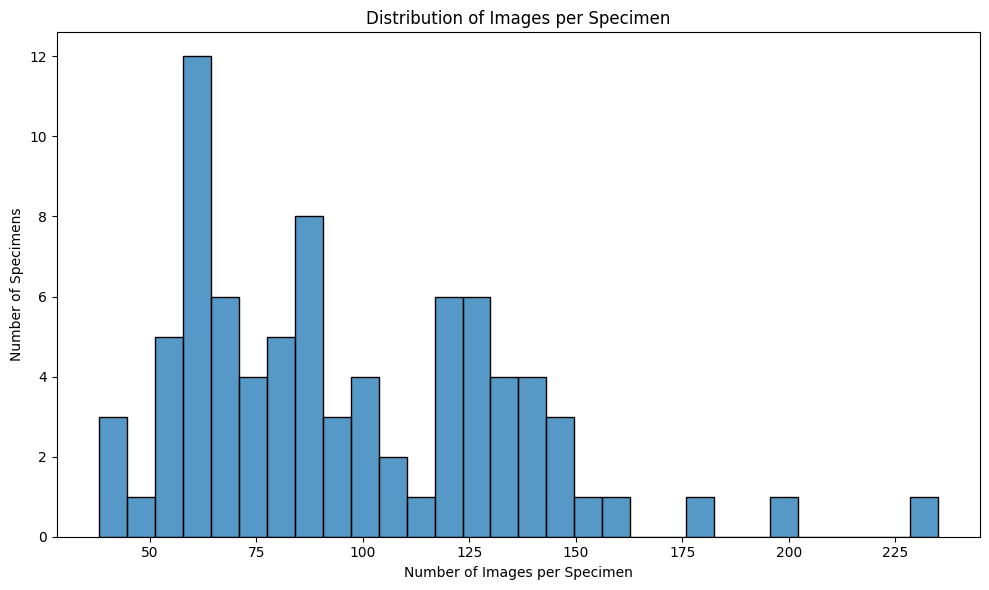

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    images_per_specimen,
    bins=30,
    kde=False
)

plt.title("Distribution of Images per Specimen")
plt.xlabel("Number of Images per Specimen")
plt.ylabel("Number of Specimens")
plt.tight_layout()
plt.show()

## 8. Specimen Distribution by Binary Class

This section examines the binary class distribution at the specimen level.
It helps identify whether specimens are distributed across both benign and
malignant categories.

In [ ]:
specimen_class_distribution = (
    dataset_df
    .groupby("specimen_id")["binary_class"]
    .nunique()
)

mixed_class_specimens = specimen_class_distribution[
    specimen_class_distribution > 1
]

print("=" * 60)
print("Specimen Class Consistency Check")
print("=" * 60)

print(
    f"Total unique specimens: "
    f"{len(specimen_class_distribution)}"
)

print(
    f"Specimens containing multiple binary classes: "
    f"{len(mixed_class_specimens)}"
)

if len(mixed_class_specimens) == 0:
    print(
        "All specimens belong to a single binary class."
    )
else:
    print(
        "Warning: Some specimens contain multiple binary classes."
    )
    display(
        dataset_df[
            dataset_df["specimen_id"].isin(
                mixed_class_specimens.index
            )
        ].sort_values("specimen_id").head(20)
    )

Specimen Class Consistency Check
Total unique specimens: 82
Specimens containing multiple binary classes: 0
All specimens belong to a single binary class.


## 9. Specimen-Level Train, Validation, and Test Split

To prevent data leakage, images belonging to the same specimen must remain
within the same dataset split.

The dataset will be divided into training, validation, and testing sets
using specimen-level grouping.

Target split proportions:

- Training: approximately 70%
- Validation: approximately 15%
- Testing: approximately 15%

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

print("=" * 60)
print("Creating Specimen-Level Dataset Splits")
print("=" * 60)

# First split: 70% training and 30% temporary data
group_split_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED
)

train_indices, temporary_indices = next(
    group_split_1.split(
        dataset_df,
        groups=dataset_df["specimen_id"]
    )
)

train_df = dataset_df.iloc[train_indices].copy()
temporary_df = dataset_df.iloc[temporary_indices].copy()

# Second split: divide temporary data into validation and test sets
# This produces approximately 15% validation and 15% test data overall.
group_split_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

validation_indices, test_indices = next(
    group_split_2.split(
        temporary_df,
        groups=temporary_df["specimen_id"]
    )
)

validation_df = temporary_df.iloc[validation_indices].copy()
test_df = temporary_df.iloc[test_indices].copy()

# Reset DataFrame indices
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training images:   {len(train_df)}")
print(f"Validation images: {len(validation_df)}")
print(f"Testing images:    {len(test_df)}")

print()
print(f"Training specimens:   {train_df['specimen_id'].nunique()}")
print(f"Validation specimens: {validation_df['specimen_id'].nunique()}")
print(f"Testing specimens:    {test_df['specimen_id'].nunique()}")

Creating Specimen-Level Dataset Splits
Training images:   5553
Validation images: 961
Testing images:    1395

Training specimens:   57
Validation specimens: 12
Testing specimens:    13


In [ ]:
print("=" * 60)
print("Specimen Leakage Verification")
print("=" * 60)

train_specimens = set(train_df["specimen_id"])
validation_specimens = set(validation_df["specimen_id"])
test_specimens = set(test_df["specimen_id"])

train_validation_overlap = (
    train_specimens.intersection(validation_specimens)
)

train_test_overlap = (
    train_specimens.intersection(test_specimens)
)

validation_test_overlap = (
    validation_specimens.intersection(test_specimens)
)

print(
    "Training–Validation overlap:",
    len(train_validation_overlap)
)

print(
    "Training–Testing overlap:",
    len(train_test_overlap)
)

print(
    "Validation–Testing overlap:",
    len(validation_test_overlap)
)

if (
    len(train_validation_overlap) == 0
    and len(train_test_overlap) == 0
    and len(validation_test_overlap) == 0
):
    print()
    print("PASS: No specimen leakage detected.")
else:
    print()
    print("WARNING: Specimen overlap detected.")

Specimen Leakage Verification
Training–Validation overlap: 0
Training–Testing overlap: 0
Validation–Testing overlap: 0

PASS: No specimen leakage detected.


Class Distribution Across Dataset Splits


,Training,Validation,Testing
binary_class,,,
Benign,1812,243,425
Malignant,3741,718,970


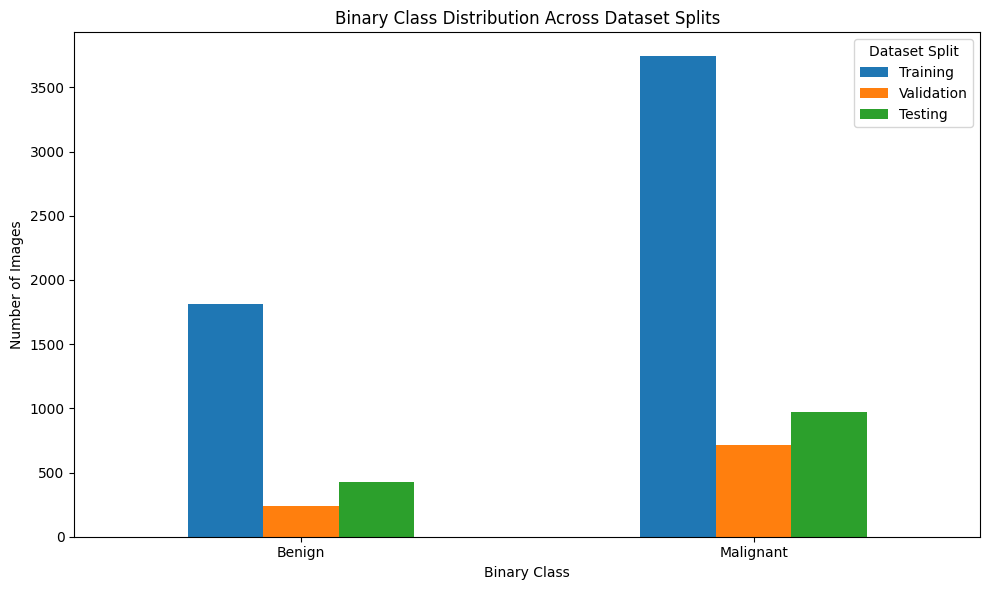

In [ ]:
print("=" * 60)
print("Class Distribution Across Dataset Splits")
print("=" * 60)

split_class_distribution = pd.DataFrame({
    "Training": train_df["binary_class"].value_counts(),
    "Validation": validation_df["binary_class"].value_counts(),
    "Testing": test_df["binary_class"].value_counts()
}).reindex(CLASS_NAMES, fill_value=0)

display(split_class_distribution)

split_class_distribution.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Binary Class Distribution Across Dataset Splits")
plt.xlabel("Binary Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()

## 10. Image Preprocessing and Data Augmentation

Images are resized to 224 × 224 pixels to provide a consistent input size
for the CNN model.

Pixel values are normalized during the input pipeline. Data augmentation
is applied only to the training dataset to improve generalization.

Validation and testing images are processed without random augmentation.

In [ ]:
print("=" * 60)
print("Defining Image Preprocessing")
print("=" * 60)

AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess_image(image_path, label):
    """
    Load an image, resize it, and normalize its pixel values.
    """

    image = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label


print("Image preprocessing function defined successfully.")

Defining Image Preprocessing
Image preprocessing function defined successfully.


In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            mode="horizontal"
        ),
        layers.RandomRotation(
            factor=0.05
        ),
        layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        )
    ],
    name="data_augmentation"
)

print("Training augmentation pipeline defined successfully.")

Training augmentation pipeline defined successfully.


In [ ]:
print("=" * 60)
print("Preparing Image Paths and Labels")
print("=" * 60)

CLASS_TO_INDEX = {
    "Benign": 0,
    "Malignant": 1
}


def prepare_paths_and_labels(dataframe):
    image_paths = dataframe["image_path"].astype(str).values

    labels = (
        dataframe["binary_class"]
        .map(CLASS_TO_INDEX)
        .astype("int32")
        .values
    )

    return image_paths, labels


train_paths, train_labels = prepare_paths_and_labels(train_df)
validation_paths, validation_labels = prepare_paths_and_labels(
    validation_df
)
test_paths, test_labels = prepare_paths_and_labels(test_df)

print(f"Training paths: {len(train_paths)}")
print(f"Validation paths: {len(validation_paths)}")
print(f"Testing paths: {len(test_paths)}")

print()
print("Class mapping:")
print(CLASS_TO_INDEX)

Preparing Image Paths and Labels
Training paths: 5553
Validation paths: 961
Testing paths: 1395

Class mapping:
{'Benign': 0, 'Malignant': 1}


In [ ]:
def create_tf_dataset(
    image_paths,
    labels,
    training=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:
        dataset = dataset.map(
            lambda image, label: (
                data_augmentation(image, training=True),
                label
            ),
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_tf_dataset(
    train_paths,
    train_labels,
    training=True
)

validation_dataset = create_tf_dataset(
    validation_paths,
    validation_labels,
    training=False
)

test_dataset = create_tf_dataset(
    test_paths,
    test_labels,
    training=False
)

print("TensorFlow dataset pipelines created successfully.")

TensorFlow dataset pipelines created successfully.


In [ ]:
print("=" * 60)
print("Inspecting Preprocessed Training Batch")
print("=" * 60)

sample_images, sample_labels = next(
    iter(train_dataset)
)

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Minimum pixel value:", tf.reduce_min(sample_images).numpy())
print("Maximum pixel value:", tf.reduce_max(sample_images).numpy())

Inspecting Preprocessed Training Batch
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.05625658
Maximum pixel value: 1.0


## 11. Visualizing Preprocessed and Augmented Images

A sample batch of training images is visualized to verify image loading,
resizing, normalization, and data augmentation.

The displayed images should retain meaningful histopathological structures
after augmentation.

Visualizing Preprocessed Training Images


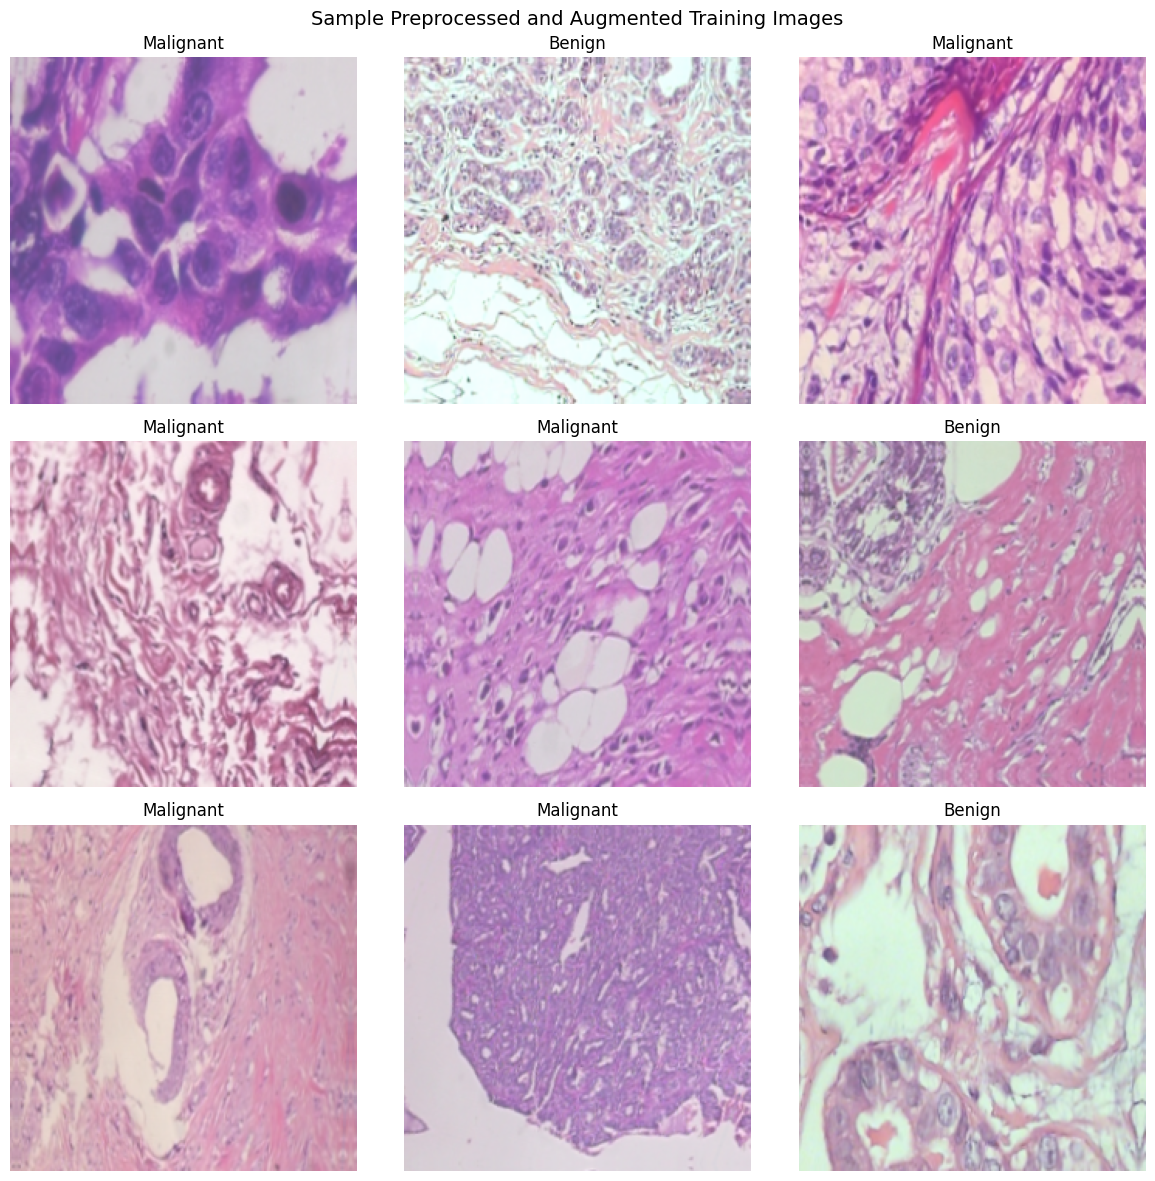

In [ ]:
print("=" * 60)
print("Visualizing Preprocessed Training Images")
print("=" * 60)

sample_images, sample_labels = next(
    iter(train_dataset)
)

plt.figure(figsize=(12, 12))

for i in range(min(9, len(sample_images))):
    plt.subplot(3, 3, i + 1)

    plt.imshow(sample_images[i].numpy())

    label_index = int(sample_labels[i].numpy())
    label_name = CLASS_NAMES[label_index]

    plt.title(label_name)
    plt.axis("off")

plt.suptitle(
    "Sample Preprocessed and Augmented Training Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("Training Batch Statistics")
print("=" * 60)

unique_labels, label_counts = np.unique(
    sample_labels.numpy(),
    return_counts=True
)

for label, count in zip(unique_labels, label_counts):
    print(
        f"{CLASS_NAMES[int(label)]}: {int(count)} images"
    )

print()
print(
    "Batch mean pixel value:",
    tf.reduce_mean(sample_images).numpy()
)

print(
    "Batch standard deviation:",
    tf.math.reduce_std(sample_images).numpy()
)

Training Batch Statistics
Benign: 11 images
Malignant: 21 images

Batch mean pixel value: 0.7266202
Batch standard deviation: 0.1639479


## 12. Baseline CNN Model

A baseline convolutional neural network is developed for binary breast cancer
classification.

The model uses convolutional layers to learn image features, pooling layers
to reduce spatial dimensions, and fully connected layers for classification.

The output layer uses a sigmoid activation function because the task contains
two binary classes: Benign and Malignant.

In [ ]:
print("=" * 60)
print("Building Baseline CNN Model")
print("=" * 60)

baseline_model = keras.Sequential(
    [
        layers.Input(
            shape=(
                IMG_HEIGHT,
                IMG_WIDTH,
                3
            )
        ),

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(
            0.5
        ),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ],
    name="baseline_cnn"
)

baseline_model.summary()

Building Baseline CNN Model


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(
            name="precision"
        ),
        keras.metrics.Recall(
            name="recall"
        ),
        keras.metrics.AUC(
            name="auc"
        )
    ]
)

print("Baseline CNN compiled successfully.")

Baseline CNN compiled successfully.


In [ ]:
checkpoint_path = MODEL_DIR / "baseline_cnn_best.keras"

baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Training callbacks defined successfully.")
print(f"Checkpoint path: {checkpoint_path}")

Training callbacks defined successfully.
Checkpoint path: /content/drive/MyDrive/CNN_Breast_Cancer/models/baseline_cnn_best.keras


## 13. Training the Baseline CNN

The baseline CNN is trained using the training dataset and evaluated on the
validation dataset after each epoch.

Early stopping, learning-rate reduction, and model checkpointing are used
to support training stability and preserve the best validation model.

In [ ]:
print("=" * 60)
print("Training Baseline CNN Model")
print("=" * 60)

EPOCHS = 25

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=baseline_callbacks,
    verbose=1
)

print()
print("Baseline CNN training completed.")

Training Baseline CNN Model
Epoch 1/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7020 - auc: 0.6826 - loss: 0.5993 - precision: 0.7232 - recall: 0.9066
Epoch 1: val_loss improved from None to 0.35680, saving model to /content/drive/MyDrive/CNN_Breast_Cancer/models/baseline_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CNN_Breast_Cancer/models/baseline_cnn_best.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 1472s 8s/step - accuracy: 0.7439 - auc: 0.7552 - loss: 0.5456 - precision: 0.7575 - recall: 0.9118 - val_accuracy: 0.8783 - val_auc: 0.9767 - val_loss: 0.3568 - val_precision: 0.9886 - val_recall: 0.8468 - learning_rate: 1.0000e-04
Epoch 2/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.7873 - auc: 0.7957 - loss: 0.5003 - precision: 0.8075 - recall: 0.8970
Epoch 2: val_loss did not improve from 0.35680
174/174 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.8044 - auc: 0.8147 - loss: 0.4806 - precision: 0.8198 - recall: 0.9096 - val_accuracy: 

Visualizing Baseline CNN Training History


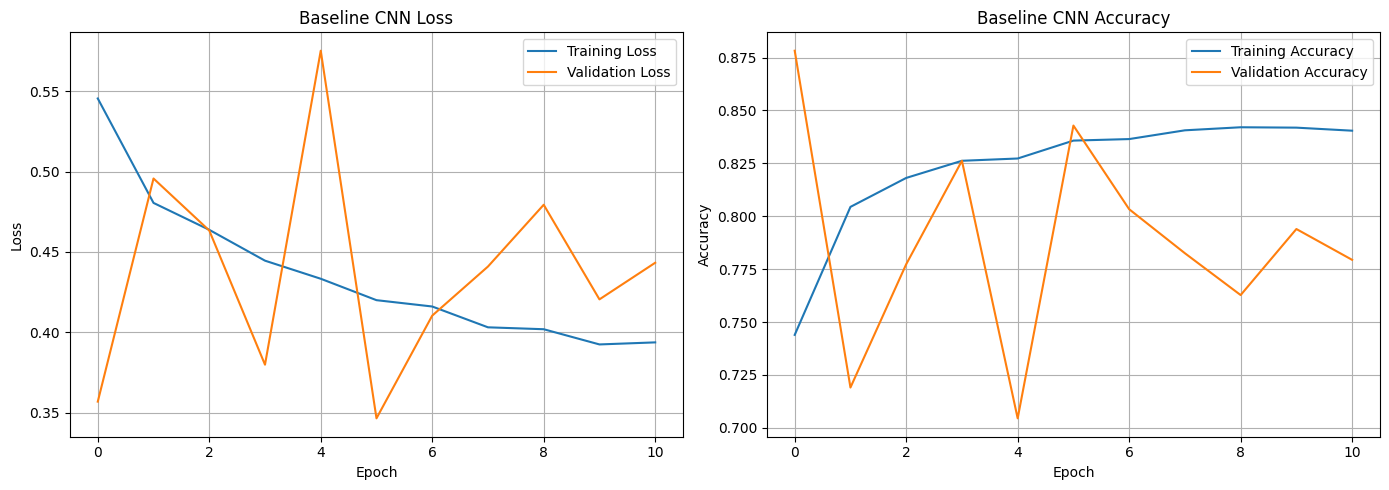

In [ ]:
print("=" * 60)
print("Visualizing Baseline CNN Training History")
print("=" * 60)

history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Loss plot
axes[0].plot(
    history_df["loss"],
    label="Training Loss"
)

axes[0].plot(
    history_df["val_loss"],
    label="Validation Loss"
)

axes[0].set_title("Baseline CNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

axes[1].plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

axes[1].set_title("Baseline CNN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 14. Baseline CNN Evaluation

The trained baseline CNN is evaluated using the validation and independent
test datasets.

The best validation results are identified using validation loss, while the
test dataset is used to assess the model's generalization performance.

Accuracy, precision, recall, and AUC are calculated for model evaluation.

In [ ]:
print("=" * 60)
print("Best Validation Results")
print("=" * 60)

history_df = pd.DataFrame(
    baseline_history.history
)

best_epoch = history_df["val_loss"].idxmin()

best_val_loss = history_df.loc[
    best_epoch,
    "val_loss"
]

best_val_accuracy = history_df.loc[
    best_epoch,
    "val_accuracy"
]

best_val_auc = history_df.loc[
    best_epoch,
    "val_auc"
]

best_val_precision = history_df.loc[
    best_epoch,
    "val_precision"
]

best_val_recall = history_df.loc[
    best_epoch,
    "val_recall"
]

print(f"Best epoch: {best_epoch + 1}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best validation AUC: {best_val_auc:.4f}")
print(f"Best validation precision: {best_val_precision:.4f}")
print(f"Best validation recall: {best_val_recall:.4f}")

Best Validation Results
Best epoch: 6
Best validation loss: 0.3464
Best validation accuracy: 0.8429
Best validation AUC: 0.9850
Best validation precision: 1.0000
Best validation recall: 0.7897


## 14. Baseline CNN Evaluation

The best baseline CNN model is evaluated on the held-out test dataset.

The evaluation includes loss, accuracy, precision, recall, and AUC.
Additional classification metrics and a confusion matrix will be calculated
in subsequent steps.

In [ ]:
print("=" * 60)
print("Evaluating Baseline CNN on Test Dataset")
print("=" * 60)

test_results = baseline_model.evaluate(
    test_dataset,
    return_dict=True,
    verbose=1
)

print()
print("Baseline CNN Test Results")

for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

Evaluating Baseline CNN on Test Dataset
44/44 ━━━━━━━━━━━━━━━━━━━━ 319s 7s/step - accuracy: 0.7885 - auc: 0.7935 - loss: 0.4971 - precision: 0.8564 - recall: 0.8361

Baseline CNN Test Results
accuracy: 0.7885
auc: 0.7935
loss: 0.4971
precision: 0.8564
recall: 0.8361


In [ ]:
print("=" * 60)
print("Generating Test Predictions")
print("=" * 60)

# Generate probability predictions
test_probabilities = baseline_model.predict(test_dataset, verbose=1).ravel()

# Convert probabilities into binary predictions
test_predictions = (test_probabilities >= 0.5).astype(int)

# True labels
test_true_labels = np.concatenate([
    labels.numpy() for _, labels in test_dataset
])

print("\nPrediction generation completed.")
print(f"Number of true labels: {len(test_true_labels)}")
print(f"Number of predictions: {len(test_predictions)}")
print(f"Number of probabilities: {len(test_probabilities)}")

Generating Test Predictions
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step

Prediction generation completed.
Number of true labels: 1395
Number of predictions: 1395
Number of probabilities: 1395


In [ ]:
print("=" * 60)
print("Detailed Classification Report")
print("=" * 60)

classification_report_result = classification_report(
    test_true_labels,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

print(classification_report_result)

Detailed Classification Report
              precision    recall  f1-score   support

      Benign     0.6451    0.6800    0.6621       425
   Malignant     0.8564    0.8361    0.8461       970

    accuracy                         0.7885      1395
   macro avg     0.7507    0.7580    0.7541      1395
weighted avg     0.7920    0.7885    0.7900      1395



Confusion Matrix


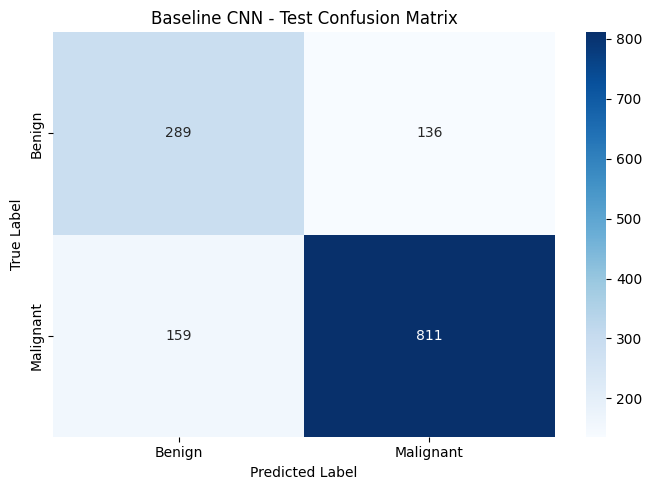

In [ ]:
print("=" * 60)
print("Confusion Matrix")
print("=" * 60)

test_cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Baseline CNN - Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("Detailed Test Dataset Metrics")
print("=" * 60)

test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_precision = precision_score(
    test_true_labels,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_true_labels,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_true_labels,
    test_predictions,
    zero_division=0
)

test_auc = roc_auc_score(
    test_true_labels,
    test_probabilities
)

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"Test AUC:       {test_auc:.4f}")

Detailed Test Dataset Metrics
Test Accuracy:  0.7885
Test Precision: 0.8564
Test Recall:    0.8361
Test F1-Score:  0.8461
Test AUC:       0.7936



## 15. Baseline CNN Results and Visualization

The baseline CNN is further evaluated using a confusion matrix, ROC curve,
and precision-recall curve.

These visualizations provide additional information about the model's
classification performance across different prediction thresholds.

The baseline test metrics are saved for comparison with subsequent models.

ROC Curve - Baseline CNN


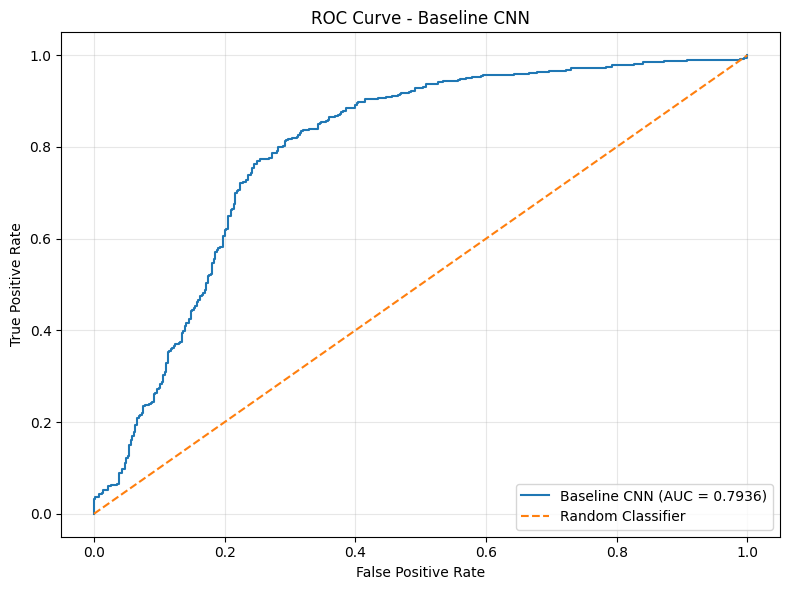

In [ ]:
print("=" * 60)
print("ROC Curve - Baseline CNN")
print("=" * 60)

fpr, tpr, roc_thresholds = roc_curve(
    test_true_labels,
    test_probabilities
)

test_auc_curve = roc_auc_score(
    test_true_labels,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Baseline CNN (AUC = {test_auc_curve:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline CNN")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Precision-Recall Curve - Baseline CNN


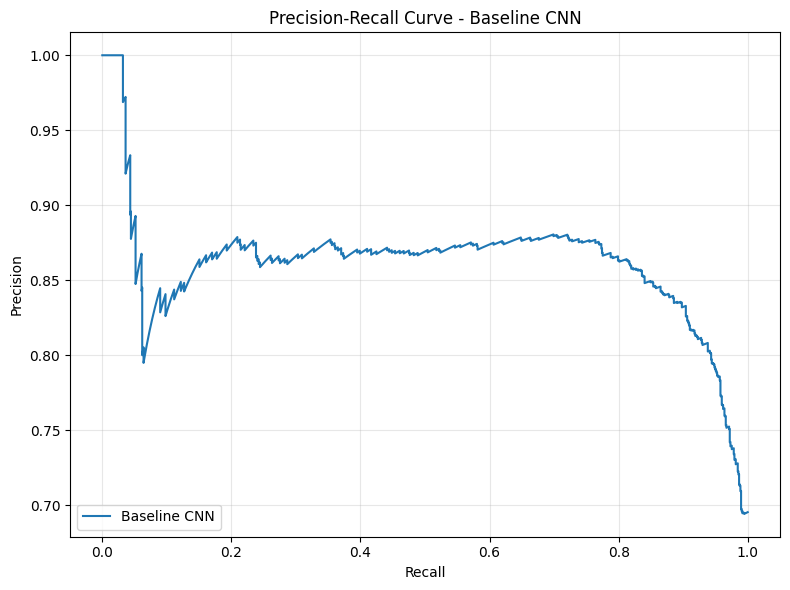

In [ ]:
print("=" * 60)
print("Precision-Recall Curve - Baseline CNN")
print("=" * 60)

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    test_true_labels,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label="Baseline CNN"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Baseline CNN")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
baseline_test_results = {
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1_score": test_f1,
    "auc": test_auc
}

baseline_results_df = pd.DataFrame(
    [baseline_test_results]
)

baseline_results_path = RESULTS_DIR / "baseline_test_results.csv"

baseline_results_df.to_csv(
    baseline_results_path,
    index=False
)

print("Baseline test results saved successfully.")
print(f"Saved to: {baseline_results_path}")

Baseline test results saved successfully.
Saved to: /content/drive/MyDrive/CNN_Breast_Cancer/results/baseline_test_results.csv



## 16. Regularized CNN Architecture

A regularized CNN is developed as an architecture experiment after the
baseline CNN.

The model uses Batch Normalization, convolutional layers, MaxPooling,
Global Average Pooling, and Dropout.

The architecture is evaluated using the same dataset splits as the baseline
CNN to support a consistent comparison.

In [ ]:
print("=" * 60)
print("Building Regularized CNN")
print("=" * 60)

regularized_model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
], name="regularized_cnn")

regularized_model.summary()

Building Regularized CNN


Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,561 (431.88 KB)

 Trainable params: 110,113 (430.13 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
print("=" * 60)
print("Compiling Regularized CNN")
print("=" * 60)

regularized_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

print("Regularized CNN compiled successfully.")

Compiling Regularized CNN
Regularized CNN compiled successfully.


In [ ]:
regularized_checkpoint_path = (
    MODEL_DIR / "regularized_cnn_best.keras"
)

regularized_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=regularized_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Regularized CNN callbacks configured.")
print(f"Checkpoint path: {regularized_checkpoint_path}")

Regularized CNN callbacks configured.
Checkpoint path: /content/drive/MyDrive/CNN_Breast_Cancer/models/regularized_cnn_best.keras



## 17. Training the Regularized CNN

The regularized CNN is trained using the training dataset and evaluated on
the validation dataset after each epoch.

Early stopping, learning-rate reduction, and model checkpointing are used
to support training stability and preserve the model with the lowest
validation loss.

The best validation epoch is recorded for subsequent test evaluation.

In [ ]:
print("=" * 60)
print("Training Regularized CNN")
print("=" * 60)

regularized_history = regularized_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=regularized_callbacks,
    verbose=1
)

print("\nRegularized CNN training completed.")

Training Regularized CNN
Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.7284 - auc: 0.7821 - loss: 0.5442 - precision: 0.8309 - recall: 0.7539
Epoch 1: val_loss improved from None to 0.59569, saving model to /content/drive/MyDrive/CNN_Breast_Cancer/models/regularized_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CNN_Breast_Cancer/models/regularized_cnn_best.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 99s 503ms/step - accuracy: 0.7933 - auc: 0.8394 - loss: 0.4600 - precision: 0.8416 - recall: 0.8538 - val_accuracy: 0.7471 - val_auc: 0.8696 - val_loss: 0.5957 - val_precision: 0.7471 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8327 - auc: 0.8955 - loss: 0.3774 - precision: 0.8491 - recall: 0.9097
Epoch 2: val_loss improved from 0.59569 to 0.46120, saving model to /content/drive/MyDrive/CNN_Breast_Cancer/models/regularized_cnn_best.keras

Epoch 2: finished saving model to /conten


## 18. Regularized CNN Evaluation on the Test Dataset

The regularized CNN is evaluated on the independent test dataset using the
same metrics as the baseline CNN.

Accuracy, precision, recall, F1-score, and AUC are calculated to measure
classification performance.

The test results are used to compare the regularized architecture with the
baseline model.

In [ ]:
print("=" * 60)
print("Evaluating Regularized CNN on Test Dataset")
print("=" * 60)

regularized_test_results = regularized_model.evaluate(
    test_dataset,
    return_dict=True,
    verbose=1
)

print("\nRegularized CNN Test Results")

for metric_name, metric_value in regularized_test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

Evaluating Regularized CNN on Test Dataset
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 367ms/step - accuracy: 0.8179 - auc: 0.8584 - loss: 0.4101 - precision: 0.8653 - recall: 0.8742

Regularized CNN Test Results
accuracy: 0.8179
auc: 0.8584
loss: 0.4101
precision: 0.8653
recall: 0.8742


In [ ]:
print("=" * 60)
print("Generating Regularized CNN Test Predictions")
print("=" * 60)

regularized_test_probabilities = (
    regularized_model.predict(
        test_dataset,
        verbose=1
    ).ravel()
)

regularized_test_predictions = (
    regularized_test_probabilities >= 0.5
).astype(int)

# Reuse the test labels collected previously
regularized_test_true_labels = test_true_labels

print("\nPrediction generation completed.")
print(
    f"Number of true labels: "
    f"{len(regularized_test_true_labels)}"
)
print(
    f"Number of predictions: "
    f"{len(regularized_test_predictions)}"
)
print(
    f"Number of probabilities: "
    f"{len(regularized_test_probabilities)}"
)

Generating Regularized CNN Test Predictions
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step

Prediction generation completed.
Number of true labels: 1395
Number of predictions: 1395
Number of probabilities: 1395


In [ ]:
print("=" * 60)
print("Regularized CNN Classification Report")
print("=" * 60)

regularized_classification_report = classification_report(
    regularized_test_true_labels,
    regularized_test_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

print(regularized_classification_report)

Regularized CNN Classification Report
              precision    recall  f1-score   support

      Benign     0.7060    0.6894    0.6976       425
   Malignant     0.8653    0.8742    0.8697       970

    accuracy                         0.8179      1395
   macro avg     0.7857    0.7818    0.7837      1395
weighted avg     0.8168    0.8179    0.8173      1395



In [ ]:
print("=" * 60)
print("Regularized CNN Classification Report")
print("=" * 60)

regularized_classification_report = classification_report(
    regularized_test_true_labels,
    regularized_test_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

print(regularized_classification_report)

Regularized CNN Classification Report
              precision    recall  f1-score   support

      Benign     0.7060    0.6894    0.6976       425
   Malignant     0.8653    0.8742    0.8697       970

    accuracy                         0.8179      1395
   macro avg     0.7857    0.7818    0.7837      1395
weighted avg     0.8168    0.8179    0.8173      1395



## 19. Baseline CNN vs Regularized CNN Comparison

The performance of the baseline CNN and regularized CNN is compared using the test dataset results.

The comparison includes accuracy, AUC, precision, recall, and loss.

The regularized CNN uses Batch Normalization, Global Average Pooling, and Dropout to reduce model complexity and improve generalization.

In [ ]:
# ============================================================
# Comparing Baseline CNN and Regularized CNN
# ============================================================

print("=" * 60)
print("Baseline CNN vs Regularized CNN")
print("=" * 60)

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AUC",
        "Loss",
        "Precision",
        "Recall"
    ],
    "Baseline CNN": [
        0.7885,
        0.7935,
        0.4971,
        0.8564,
        0.8361
    ],
    "Regularized CNN": [
        0.8179,
        0.8584,
        0.4101,
        0.8653,
        0.8742
    ]
})

comparison_df["Difference"] = (
    comparison_df["Regularized CNN"] -
    comparison_df["Baseline CNN"]
)

display(comparison_df)

Baseline CNN vs Regularized CNN


,Metric,Baseline CNN,Regularized CNN,Difference
0,Accuracy,0.7885,0.8179,0.0294
1,AUC,0.7935,0.8584,0.0649
2,Loss,0.4971,0.4101,-0.0870
3,Precision,0.8564,0.8653,0.0089
4,Recall,0.8361,0.8742,0.0381


In [ ]:
# ============================================================
# Comparing Baseline CNN and Regularized CNN
# ============================================================

print("=" * 60)
print("Baseline CNN vs Regularized CNN")
print("=" * 60)

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AUC",
        "Loss",
        "Precision",
        "Recall"
    ],
    "Baseline CNN": [
        0.7885,
        0.7935,
        0.4971,
        0.8564,
        0.8361
    ],
    "Regularized CNN": [
        0.8179,
        0.8584,
        0.4101,
        0.8653,
        0.8742
    ]
})

comparison_df["Difference"] = (
    comparison_df["Regularized CNN"] -
    comparison_df["Baseline CNN"]
)

display(comparison_df)

Baseline CNN vs Regularized CNN


,Metric,Baseline CNN,Regularized CNN,Difference
0,Accuracy,0.7885,0.8179,0.0294
1,AUC,0.7935,0.8584,0.0649
2,Loss,0.4971,0.4101,-0.0870
3,Precision,0.8564,0.8653,0.0089
4,Recall,0.8361,0.8742,0.0381


## 20. Evaluation Summary

The baseline CNN achieved a test accuracy of 78.85% and a test AUC of approximately 79.35%.

The regularized CNN achieved a test accuracy of 81.79% and a test AUC of 85.84%.

The regularized CNN also produced a lower test loss and higher recall than the baseline CNN.

The classification report indicates that the regularized CNN performs better on the Malignant class than on the Benign class. Therefore, class-wise metrics should be considered alongside overall accuracy.

The results will be further examined using a confusion matrix, ROC curve, precision-recall curve, and additional evaluation techniques.

## 21. Regularized CNN Confusion Matrix

A confusion matrix is used to examine the classification results for the Benign and Malignant classes.

It shows the number of correctly and incorrectly classified samples for each class.

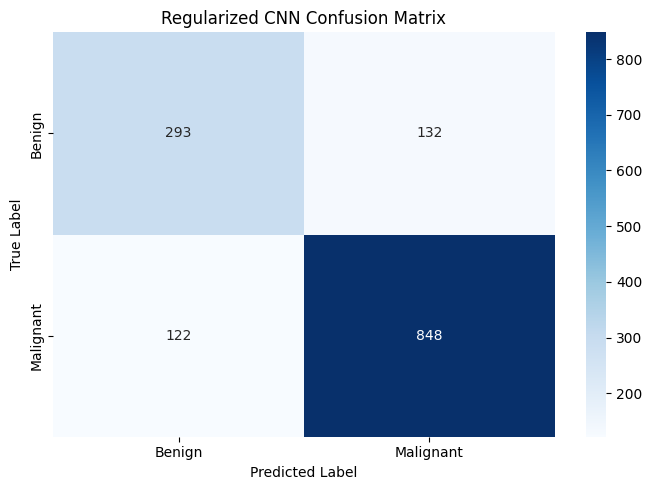

In [ ]:
# ============================================================
# Regularized CNN Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

regularized_cm = confusion_matrix(
    regularized_test_true_labels,
    regularized_test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    regularized_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Regularized CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 22. Regularized CNN ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the ability of the regularized CNN to distinguish between Benign and Malignant samples across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's discrimination performance.

Regularized CNN ROC Curve


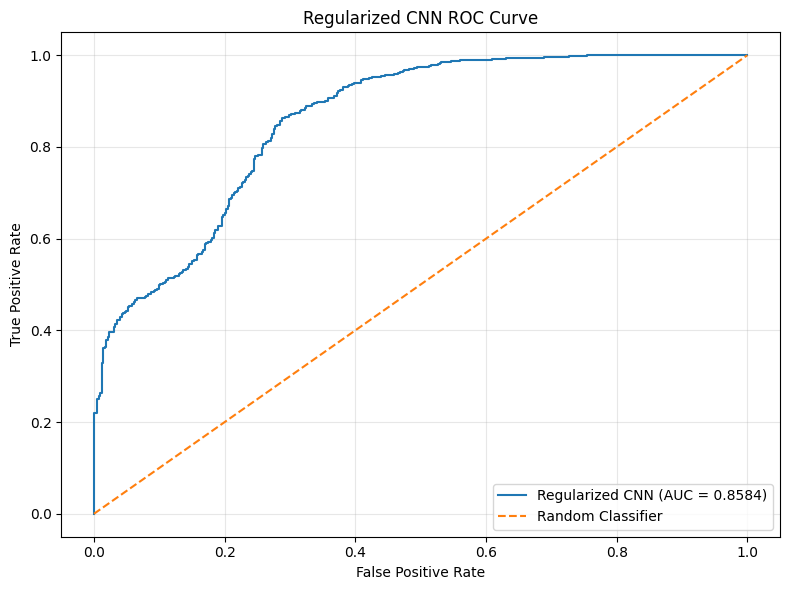

Regularized CNN Test AUC: 0.8584


In [ ]:
# ============================================================
# Regularized CNN ROC Curve
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

print("=" * 60)
print("Regularized CNN ROC Curve")
print("=" * 60)

regularized_fpr, regularized_tpr, regularized_thresholds = roc_curve(
    regularized_test_true_labels,
    regularized_test_probabilities
)

regularized_roc_auc = roc_auc_score(
    regularized_test_true_labels,
    regularized_test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    regularized_fpr,
    regularized_tpr,
    label=f"Regularized CNN (AUC = {regularized_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Regularized CNN ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Regularized CNN Test AUC: {regularized_roc_auc:.4f}")

## 23. Regularized CNN Precision-Recall Curve

The Precision-Recall curve shows the relationship between precision and recall at different classification thresholds.

This curve provides additional information about the model's performance when the classes are imbalanced.

Regularized CNN Precision-Recall Curve


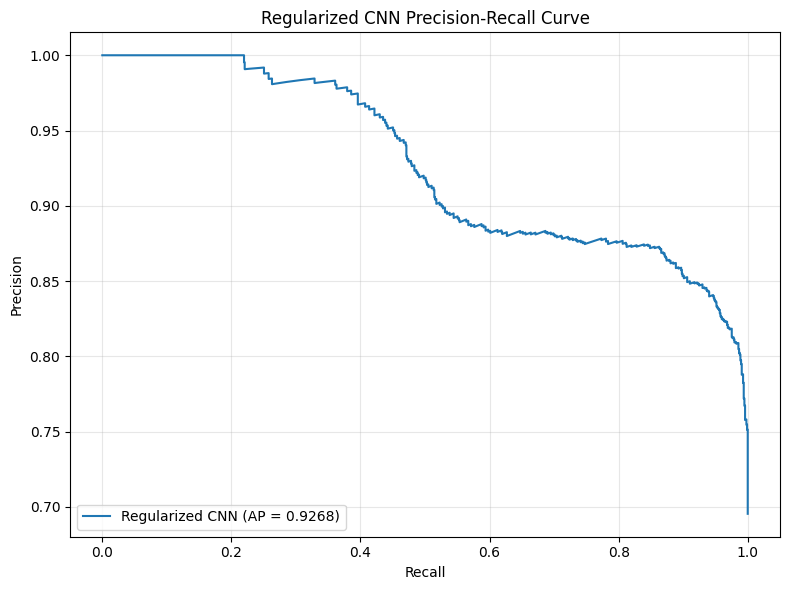

Regularized CNN Average Precision: 0.9268


In [ ]:
# ============================================================
# Regularized CNN Precision-Recall Curve
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

print("=" * 60)
print("Regularized CNN Precision-Recall Curve")
print("=" * 60)

regularized_precision, regularized_recall, regularized_pr_thresholds = (
    precision_recall_curve(
        regularized_test_true_labels,
        regularized_test_probabilities
    )
)

regularized_average_precision = average_precision_score(
    regularized_test_true_labels,
    regularized_test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    regularized_recall,
    regularized_precision,
    label=f"Regularized CNN (AP = {regularized_average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Regularized CNN Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Regularized CNN Average Precision: "
    f"{regularized_average_precision:.4f}"
)

## 24. Saving Regularized CNN Test Results

The test predictions, predicted probabilities, true labels, and evaluation results are saved for future analysis and reporting.

Saving the results ensures that the evaluation can be reviewed without repeating model prediction.

In [ ]:
# ============================================================
# Saving Regularized CNN Test Results
# ============================================================

regularized_results_df = pd.DataFrame({
    "true_label": regularized_test_true_labels,
    "predicted_label": regularized_test_predictions,
    "predicted_probability": regularized_test_probabilities
})

regularized_predictions_path = (
    RESULTS_DIR / "regularized_cnn_test_predictions.csv"
)

regularized_results_df.to_csv(
    regularized_predictions_path,
    index=False
)

print("Regularized CNN predictions saved successfully.")
print(f"Saved file: {regularized_predictions_path}")
print(f"Number of saved predictions: {len(regularized_results_df)}")

Regularized CNN predictions saved successfully.
Saved file: /content/drive/MyDrive/CNN_Breast_Cancer/results/regularized_cnn_test_predictions.csv
Number of saved predictions: 1395


In [ ]:
# ============================================================
# Saving Regularized CNN Evaluation Metrics
# ============================================================

regularized_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AUC",
        "Loss",
        "Precision",
        "Recall",
        "F1-Score",
        "Average Precision"
    ],
    "Value": [
        regularized_test_results["accuracy"],
        regularized_test_results["auc"],
        regularized_test_results["loss"],
        regularized_test_results["precision"],
        regularized_test_results["recall"],
        f1_score(
            regularized_test_true_labels,
            regularized_test_predictions
        ),
        regularized_average_precision
    ]
})

regularized_summary_path = (
    RESULTS_DIR / "regularized_cnn_summary_metrics.csv"
)

regularized_summary.to_csv(
    regularized_summary_path,
    index=False
)

display(regularized_summary)

print(f"Summary metrics saved to: {regularized_summary_path}")

,Metric,Value
0,Accuracy,0.817921
1,AUC,0.858426
2,Loss,0.410078
3,Precision,0.865306
4,Recall,0.874227
5,F1-Score,0.869744
6,Average Precision,0.926786


Summary metrics saved to: /content/drive/MyDrive/CNN_Breast_Cancer/results/regularized_cnn_summary_metrics.csv


## 25. Individual Image Prediction

A single test image is selected to demonstrate how the trained regularized CNN makes a prediction.

The image is displayed along with its true class, predicted class, and predicted probability.

Individual Image Prediction


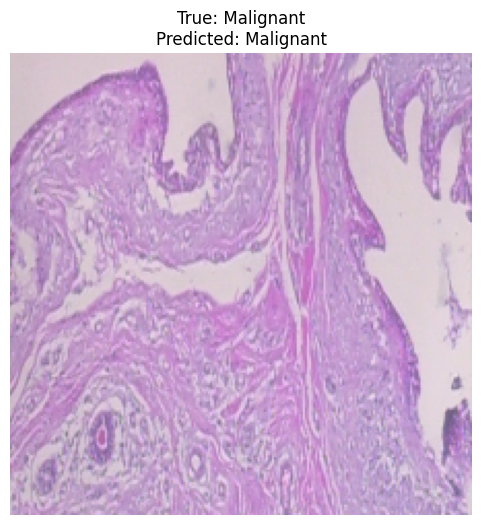

Image Path: /content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse/40X/ductal_carcinoma/SOB_M_DC-14-17915-40-013.png
True Label: Malignant
Predicted Label: Malignant
Malignant Probability: 0.9896
Benign Probability: 0.0104


In [ ]:
# ============================================================
# Individual Image Prediction
# ============================================================

import random

print("=" * 60)
print("Individual Image Prediction")
print("=" * 60)

# Select one image from the test dataset
sample_row = test_df.sample(
    n=1,
    random_state=SEED
).iloc[0]

sample_image_path = Path(sample_row["image_path"])
sample_true_label = sample_row["binary_class"]

# Load and preprocess image
sample_image = Image.open(sample_image_path).convert("RGB")
sample_image_resized = sample_image.resize(IMAGE_SIZE)

sample_image_array = np.array(
    sample_image_resized
).astype("float32") / 255.0

sample_input = np.expand_dims(
    sample_image_array,
    axis=0
)

# Generate prediction
sample_probability = regularized_model.predict(
    sample_input,
    verbose=0
)[0][0]

sample_prediction_index = int(
    sample_probability >= 0.5
)

sample_predicted_label = CLASS_NAMES[
    sample_prediction_index
]

# Display image and results
plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(
    f"True: {sample_true_label}\n"
    f"Predicted: {sample_predicted_label}"
)
plt.show()

print(f"Image Path: {sample_image_path}")
print(f"True Label: {sample_true_label}")
print(f"Predicted Label: {sample_predicted_label}")
print(f"Malignant Probability: {sample_probability:.4f}")
print(
    f"Benign Probability: "
    f"{1 - sample_probability:.4f}"
)

## 26. Saving and Reloading the Regularized CNN

The trained regularized CNN is saved in Keras format.

The saved model is then reloaded to verify that it can be restored and used for evaluation.

In [ ]:
# ============================================================
# Saving Regularized CNN Model
# ============================================================

regularized_final_model_path = (
    MODEL_DIR / "regularized_cnn_final.keras"
)

regularized_model.save(
    regularized_final_model_path
)

print("Regularized CNN model saved successfully.")
print(f"Saved model path: {regularized_final_model_path}")

Regularized CNN model saved successfully.
Saved model path: /content/drive/MyDrive/CNN_Breast_Cancer/models/regularized_cnn_final.keras


In [ ]:
# ============================================================
# Saving Regularized CNN Model
# ============================================================

regularized_final_model_path = (
    MODEL_DIR / "regularized_cnn_final.keras"
)

regularized_model.save(
    regularized_final_model_path
)

print("Regularized CNN model saved successfully.")
print(f"Saved model path: {regularized_final_model_path}")

Regularized CNN model saved successfully.
Saved model path: /content/drive/MyDrive/CNN_Breast_Cancer/models/regularized_cnn_final.keras


In [ ]:
# ============================================================
# Reloading Regularized CNN Model
# ============================================================

reloaded_regularized_model = keras.models.load_model(
    regularized_final_model_path
)

print("Regularized CNN model reloaded successfully.")
reloaded_regularized_model.summary()

Regularized CNN model reloaded successfully.


Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,789 (1.26 MB)

 Trainable params: 110,113 (430.13 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 220,228 (860.27 KB)

## 27. Final Model Performance Comparison

The baseline CNN and regularized CNN are compared using the test dataset.

The comparison includes accuracy, AUC, loss, precision, recall, and F1-score.

In [ ]:
# ============================================================
# Final Model Performance Comparison
# ============================================================

baseline_f1 = f1_score(
    test_true_labels,
    test_predictions
)

regularized_f1 = f1_score(
    regularized_test_true_labels,
    regularized_test_predictions
)

final_comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AUC",
        "Loss",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Baseline CNN": [
        0.7885,
        0.7935,
        0.4971,
        0.8564,
        0.8361,
        baseline_f1
    ],
    "Regularized CNN": [
        0.8179,
        0.8584,
        0.4101,
        0.8653,
        0.8742,
        regularized_f1
    ]
})

final_comparison_df["Difference"] = (
    final_comparison_df["Regularized CNN"] -
    final_comparison_df["Baseline CNN"]
)

display(final_comparison_df)

final_comparison_path = (
    RESULTS_DIR / "final_model_comparison.csv"
)

final_comparison_df.to_csv(
    final_comparison_path,
    index=False
)

print(f"Final comparison saved to: {final_comparison_path}")

,Metric,Baseline CNN,Regularized CNN,Difference
0,Accuracy,0.788500,0.817900,0.02940
1,AUC,0.793500,0.858400,0.06490
2,Loss,0.497100,0.410100,-0.08700
3,Precision,0.856400,0.865300,0.00890
4,Recall,0.836100,0.874200,0.03810
5,F1-Score,0.846114,0.869744,0.02363


Final comparison saved to: /content/drive/MyDrive/CNN_Breast_Cancer/results/final_model_comparison.csv


# 28. Final Project Summary

## Project Overview

This project developed a Convolutional Neural Network (CNN) for binary classification of breast histopathology images into Benign and Malignant categories.

The BreaKHis dataset was processed using image resizing, normalization, data augmentation, and specimen-level dataset splitting.

## Dataset Preparation

The dataset contained 7,909 image records in the selected multiclass directory.

The images were grouped into Benign and Malignant categories using the predefined subtype mapping.

A specimen-level split was used to reduce the risk of data leakage between the training, validation, and test datasets.

The dataset was divided into:

- Training set: 5,553 images
- Validation set: 961 images
- Test set: 1,395 images

## Models Developed

Two CNN architectures were evaluated:

1. Baseline CNN
2. Regularized CNN

The regularized CNN included Batch Normalization, Global Average Pooling, and Dropout.

## Model Performance

The baseline CNN achieved the following test results:

- Accuracy: 78.85%
- AUC: 79.35%
- Precision: 85.64%
- Recall: 83.61%
- Loss: 0.4971

The regularized CNN achieved the following test results:

- Accuracy: 81.79%
- AUC: 85.84%
- Precision: 86.53%
- Recall: 87.42%
- Loss: 0.4101

## Classification Performance

The regularized CNN achieved the following class-wise results:

### Benign

- Precision: 70.60%
- Recall: 68.94%
- F1-score: 69.76%

### Malignant

- Precision: 86.53%
- Recall: 87.42%
- F1-score: 86.97%

The class-wise results indicate that the model's performance differs between the Benign and Malignant classes.

## Evaluation Methods

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- AUC
- Confusion matrix
- ROC curve
- Precision-Recall curve
- Individual image prediction

## Conclusion

The regularized CNN achieved higher reported test accuracy, AUC, precision, and recall than the baseline CNN, together with lower test loss.

The results demonstrate the importance of evaluating multiple metrics rather than relying only on accuracy.

The model's performance should be interpreted as an experimental image-classification result and should not be considered a clinical diagnostic system without further validation.

In [ ]:
# ============================================================
# Final Project File Verification
# ============================================================

print("=" * 60)
print("Final Project File Verification")
print("=" * 60)

print("\nModel Files:")

for file_path in MODEL_DIR.iterdir():
    if file_path.is_file():
        print(f"✓ {file_path.name}")

print("\nResult Files:")

for file_path in RESULTS_DIR.iterdir():
    if file_path.is_file():
        print(f"✓ {file_path.name}")

print("\nProject completion verification finished.")

Final Project File Verification

Model Files:
✓ baseline_cnn_best.keras
✓ regularized_cnn_best.keras
✓ regularized_cnn_final.keras

Result Files:
✓ baseline_test_results.csv
✓ regularized_cnn_test_predictions.csv
✓ regularized_cnn_summary_metrics.csv
✓ final_model_comparison.csv

Project completion verification finished.


## 30. Random Test Image Classification Using the Saved Model

The saved Regularized CNN model is used to classify a randomly selected image from the test dataset.

The selected image is preprocessed using the same image resizing and normalization procedure used during model training.

The output includes:

- The randomly selected image.
- The true class label.
- The predicted class label.
- The probability of the image being Benign.
- The probability of the image being Malignant.

This experiment demonstrates how the saved model performs classification on an individual test image.

**Note:** The model output is intended for experimental evaluation and should not be considered a clinical diagnosis.

Loading Saved Regularized CNN Model
Saved model loaded successfully.
Model path: /content/drive/MyDrive/CNN_Breast_Cancer/models/regularized_cnn_final.keras

Selecting a Random Test Image

Generating Prediction


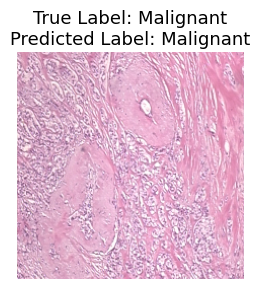


Random Image Classification Results
Image Path: /content/drive/MyDrive/CNN_Breast_Cancer/extracted_dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse/40X/ductal_carcinoma/SOB_M_DC-14-13993-40-006.png
True Label: Malignant
Predicted Label: Malignant
Benign Probability: 0.2461 (24.61%)
Malignant Probability: 0.7539 (75.39%)
Classification Threshold: 0.50


In [ ]:
# ============================================================
# Random Test Image Classification Using Saved Model
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from PIL import Image
from tensorflow import keras


# ============================================================
# 1. Load the Saved Regularized CNN Model
# ============================================================

print("=" * 60)
print("Loading Saved Regularized CNN Model")
print("=" * 60)

# Saved model path
SAVED_MODEL_PATH = (
    MODEL_DIR / "regularized_cnn_final.keras"
)

# Load the trained model
saved_model = keras.models.load_model(
    SAVED_MODEL_PATH
)

print("Saved model loaded successfully.")
print(f"Model path: {SAVED_MODEL_PATH}")


# ============================================================
# 2. Select a Random Image from the Test Dataset
# ============================================================

print("\n" + "=" * 60)
print("Selecting a Random Test Image")
print("=" * 60)

# Use a random test image
random_index = np.random.randint(
    0,
    len(test_df)
)

random_sample = test_df.iloc[random_index]

random_image_path = Path(
    random_sample["image_path"]
)

true_label = random_sample["binary_class"]


# ============================================================
# 3. Load and Preprocess the Image
# ============================================================

# Open image and convert it to RGB
original_image = Image.open(
    random_image_path
).convert("RGB")

# Resize image to the model input size
resized_image = original_image.resize(
    IMAGE_SIZE
)

# Convert image to NumPy array
image_array = np.array(
    resized_image
).astype("float32")

# Normalize pixel values to the range [0, 1]
image_array = image_array / 255.0

# Add batch dimension
model_input = np.expand_dims(
    image_array,
    axis=0
)


# ============================================================
# 4. Generate Model Prediction
# ============================================================

print("\n" + "=" * 60)
print("Generating Prediction")
print("=" * 60)

# Sigmoid output represents the Malignant probability
malignant_probability = float(
    saved_model.predict(
        model_input,
        verbose=0
    )[0][0]
)

# Calculate Benign probability
benign_probability = 1.0 - malignant_probability

# Apply classification threshold
prediction_index = int(
    malignant_probability >= 0.5
)

# Convert prediction index into class label
predicted_label = CLASS_NAMES[
    prediction_index
]


# ============================================================
# 5. Display the Image
# ============================================================

plt.figure(figsize=(3, 3))

plt.imshow(original_image)
plt.axis("off")

plt.title(
    f"True Label: {true_label}\n"
    f"Predicted Label: {predicted_label}",
    fontsize=13
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. Display Classification Results
# ============================================================

print("\n" + "=" * 60)
print("Random Image Classification Results")
print("=" * 60)

print(f"Image Path: {random_image_path}")
print(f"True Label: {true_label}")
print(f"Predicted Label: {predicted_label}")

print(
    f"Benign Probability: "
    f"{benign_probability:.4f} "
    f"({benign_probability * 100:.2f}%)"
)

print(
    f"Malignant Probability: "
    f"{malignant_probability:.4f} "
    f"({malignant_probability * 100:.2f}%)"
)

print(
    f"Classification Threshold: 0.50"
)

print("=" * 60)